In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import mixture

In [15]:
flow_data = np.load('./01-Well-B1.npy')

print('Here are the channel names:')
print(flow_data.dtype.names)

Here are the channel names:
('FSC-H', 'FSC-A', 'SSC-H', 'SSC-A', 'FL1-H', 'FL1-A', 'FL6-H', 'FL6-A', 'FL10-H', 'FL10-A', 'FL11-H', 'FL11-A', 'FSC-Width', 'Time')


In [88]:
# convert to regular numpy array, and filter out <0 elements
flow_2d = np.vstack([flow_data['FSC-A'], flow_data['FL1-A']]).T
flow_2d = flow_2d[np.all(flow_2d > 0, axis=1), :]

print(flow_2d)

[[263884.40625      9520.90039062]
 [311377.3125      20583.        ]
 [301207.1875       1250.59997559]
 ...
 [248362.59375      5657.        ]
 [613565.125        6885.89990234]
 [298074.59375      1464.69995117]]


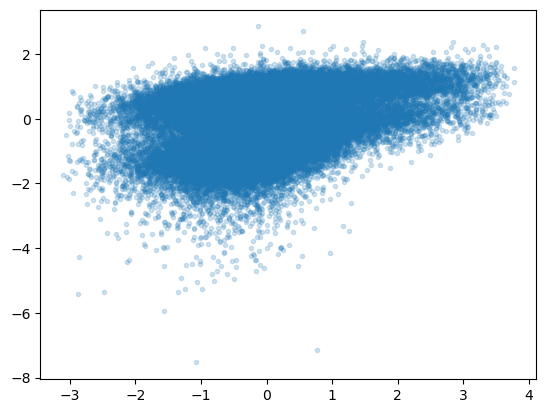

In [114]:
# transform and standardize data before clustering
cluster_input = flow_2d.copy()
cluster_input = np.log(cluster_input)
cluster_input = (cluster_input - np.mean(cluster_input, axis=0)) / np.std(cluster_input, axis=0)

plt.plot(cluster_input[:, 0], cluster_input[:, 1], '.', alpha=0.2)

In [116]:
clf2 = mixture.GaussianMixture(n_components=2, covariance_type="full")
clf2.fit(cluster_input)

GaussianMixture(n_components=2)

Text(0, 0.5, 'FITC-A')

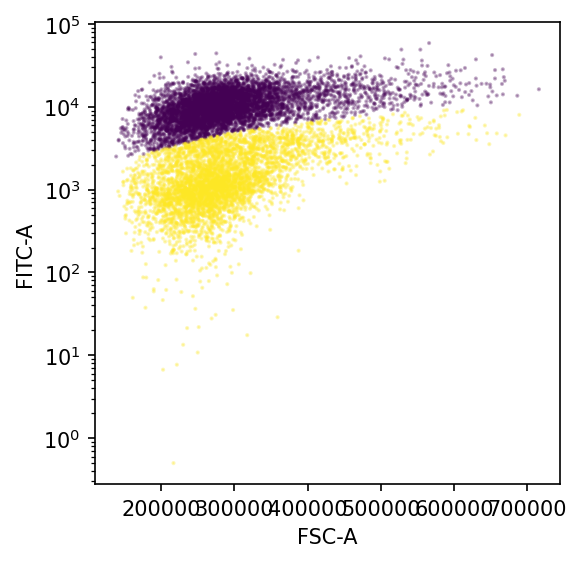

In [133]:
sub_sample_index = np.random.choice(np.arange(len(flow_2d)), 10000, replace=False)

fig, ax = plt.subplots(figsize=[4,4])
fig.dpi = 150
ax.scatter(x=flow_2d[sub_sample_index,0], y=flow_2d[sub_sample_index,1], c=clf2.predict(cluster_input[sub_sample_index, :]) + 1, alpha=0.3, s=1)
ax.set_yscale('log')
ax.set_xlabel('FSC-A')
ax.set_ylabel('FITC-A')